# Predictive Insight Engine

# Part A: Conceptual Understanding (Theory)

### Q1. What are Supervised Learning Algorithms?
Supervised learning algorithms learn from **labelled data**, where every input (features `X`) has a known output (target `y`). The model learns the mapping `y = f(X)` and then predicts the output for new, unseen data. Examples: Linear Regression, Logistic Regression, Decision Tree, SVM, KNN. Example use: predicting house price from area, rooms and location.

### Q2. Regression vs Classification Algorithms
| Point | Regression | Classification |
|---|---|---|
| Output | Continuous number | Discrete class / label |
| Example | House price = ₹52.4 lakh | Email = Spam / Not Spam |
| Algorithms | Linear, Polynomial, Ridge, Lasso | Logistic, KNN, SVM, Decision Tree |
| Metrics | MSE, MAE, RMSE, R² | Accuracy, Precision, Recall, F1 |

### Q3. Simple Linear Regression
Simple Linear Regression models the relationship between **one independent variable (x)** and **one dependent variable (y)** with a straight line:
**y = β₀ + β₁x** where β₀ = intercept (value of y when x = 0) and β₁ = slope (change in y for one unit change in x).
The best-fit line is found by minimising the **sum of squared errors (Least Squares)**. Example: House Price = β₀ + β₁ × House Area.

### Q4. Assumptions of Linear Regression
1. **Linearity** – relationship between X and y is linear.
2. **Independence of errors** – residuals are not correlated with each other (no autocorrelation).
3. **Homoscedasticity** – residuals have constant variance at all levels of predicted values.
4. **Normality of residuals** – errors are approximately normally distributed.
5. **No multicollinearity** – (for multiple regression) independent variables are not highly correlated with each other.

### Q5. Bias–Variance Trade-Off
- **Bias** = error from wrong/too simple assumptions (model misses the pattern → underfitting).
- **Variance** = error from too much sensitivity to training data (model learns noise → overfitting).
- Total Error = Bias² + Variance + Irreducible Error.
- Simple models → high bias, low variance. Complex models → low bias, high variance. The **trade-off** is to find the complexity where total test error is minimum.

### Q6. Overfitting and Underfitting
- **Underfitting:** Model is too simple, performs badly on **both** train and test data. *Example:* fitting a straight line to a clearly curved price-vs-area relation (Train R² = 0.55, Test R² = 0.52).
- **Overfitting:** Model is too complex, performs very well on train but badly on test data. *Example:* degree-15 polynomial passing through every training point (Train R² = 0.99, Test R² = 0.60).
- **Good fit:** Train and test scores are both high and close to each other.

### Setup: Import Libraries

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs("plots", exist_ok=True)

# Part B: Dataset Understanding & Preparation

In [2]:
DATA_PATH = "RealEstate_HousePrice_Dataset.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print("Loaded real dataset:", DATA_PATH)
else:
    print("CSV not found")
    
df = df.drop(columns=["house_id"], errors="ignore")

df.head()

Loaded real dataset: RealEstate_HousePrice_Dataset.csv


,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [3]:
print("Shape:", df.shape)

Shape: (4200, 11)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area_sqft             4200 non-null   int64  
 1   bedrooms              4200 non-null   int64  
 2   bathrooms             4200 non-null   int64  
 3   location_score        4200 non-null   float64
 4   age_years             4200 non-null   int64  
 5   distance_city_km      4200 non-null   float64
 6   lot_size_sqft         4200 non-null   int64  
 7   has_garage            4200 non-null   int64  
 8   has_pool              4200 non-null   int64  
 9   renovation_years_ago  4200 non-null   int64  
 10  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 361.1 KB


In [5]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64


In [6]:
df.describe()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


In [7]:
df = df.drop_duplicates()
df = df.fillna(df.median(numeric_only=True))
print("Clean shape:", df.shape)

Clean shape: (4200, 11)


### Q7. Independent and Dependent Variables

In [8]:
FEATURES = ["area_sqft", "bedrooms", "bathrooms", "location_score", "age_years",
            "distance_city_km", "lot_size_sqft", "has_garage", "has_pool", "renovation_years_ago"]
TARGET   = "house_price_inr"

X = df[FEATURES]      
y = df[TARGET] 

print("Independent variables (X):", FEATURES)
print("Dependent variable   (y):", TARGET)

Independent variables (X): ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool', 'renovation_years_ago']
Dependent variable   (y): house_price_inr


### Q8. Visualize relationships between features and target

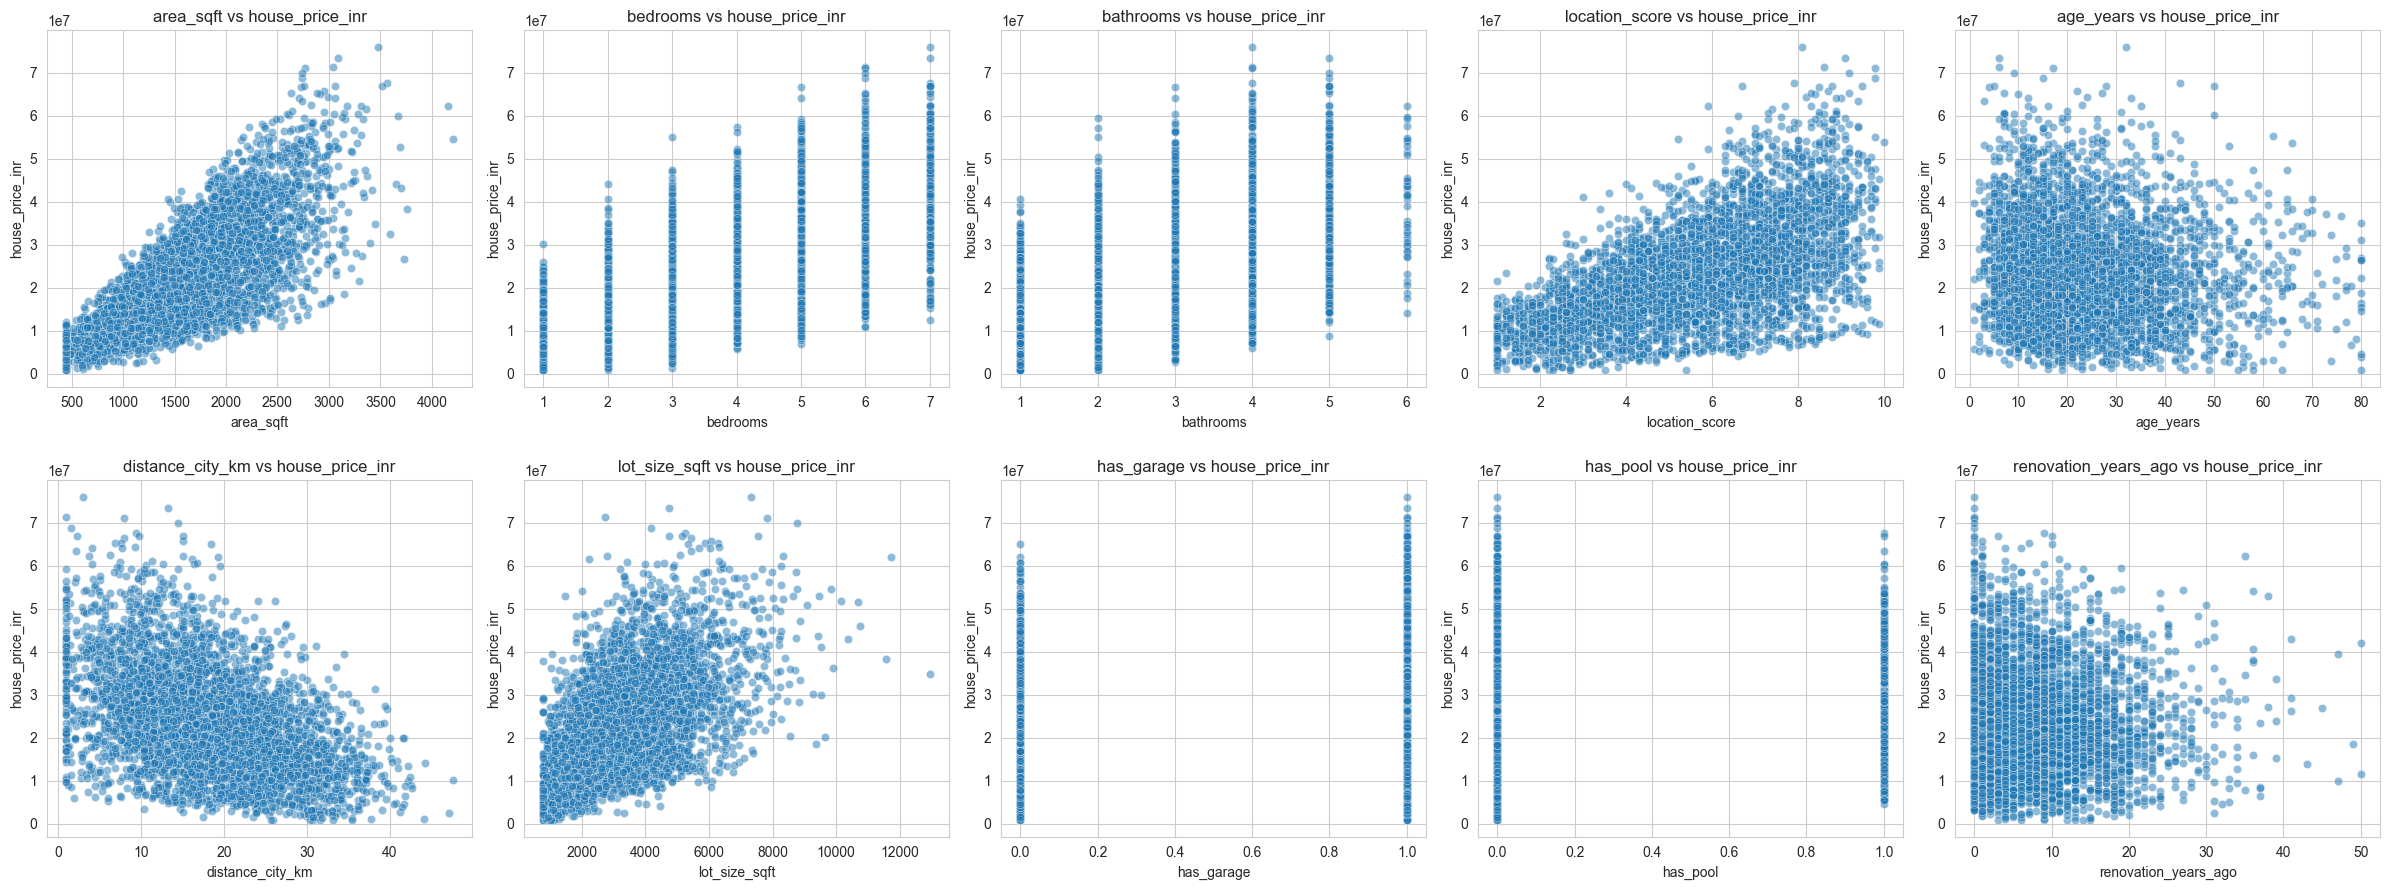

In [9]:
# 1) Scatter plot of each feature vs price
fig, axes = plt.subplots(2, 5, figsize=(24, 9))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.scatterplot(x=df[col], y=df[TARGET], ax=ax, alpha=0.5)
    ax.set_title(f"{col} vs {TARGET}")
plt.tight_layout(); plt.savefig("plots/01_scatter_features_vs_price.png", dpi=120); plt.show()

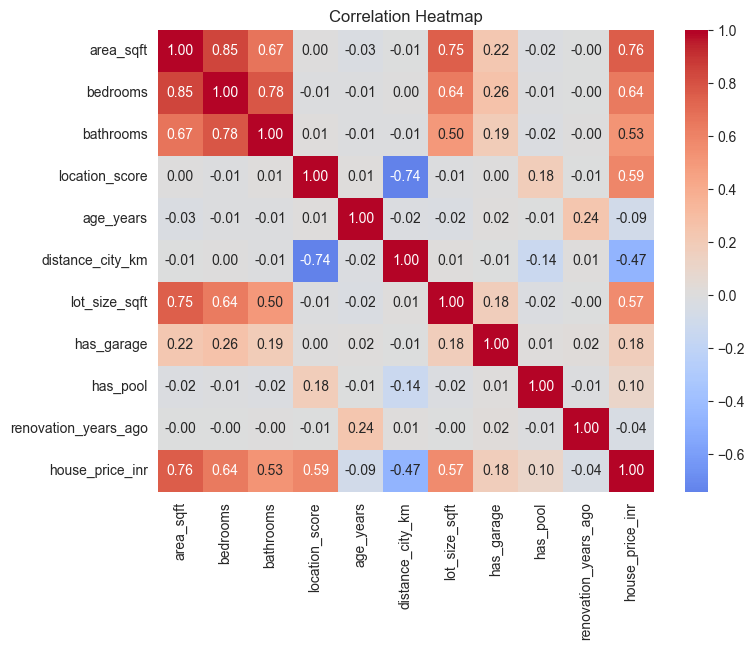

In [10]:
# 2) Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.savefig("plots/02_correlation_heatmap.png", dpi=120); plt.show()

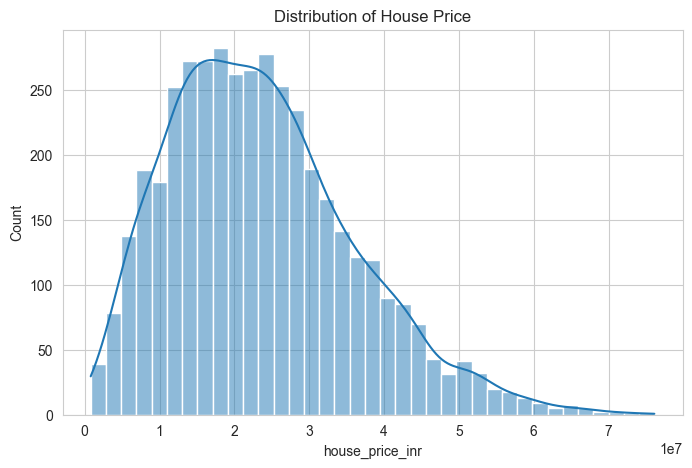

In [11]:
# 3) Distribution of target
plt.figure()
sns.histplot(df[TARGET], kde=True)
plt.title("Distribution of House Price")
plt.savefig("plots/03_price_distribution.png", dpi=120); plt.show()

**Interpretation:** House Area (and usually Location Score) shows a strong positive relationship with price, so price increases as these increase. `age_years` and `distance_city_km` usually show a negative relationship (older / farther house → lower price). The heatmap also shows which features are correlated with each other (e.g. area, bedrooms, bathrooms, lot size) which is important for multicollinearity.

### Q9. Split the dataset into Training and Testing sets

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (3360, 10)  Test size: (840, 10)


# Part C: Simple Linear Regression

### Q10. Implement Simple Linear Regression (feature = House Area)

In [13]:
Xtr_area = X_train[["area_sqft"]]
Xte_area = X_test[["area_sqft"]]

slr = LinearRegression()
slr.fit(Xtr_area, y_train)

slr_train_pred = slr.predict(Xtr_area)
slr_test_pred  = slr.predict(Xte_area)

print("Intercept (β0):", slr.intercept_)
print("Slope     (β1):", slr.coef_[0])

Intercept (β0): -1163519.1764186025
Slope     (β1): 14788.306111307536


### Q11. Plot the regression line and interpret slope & intercept

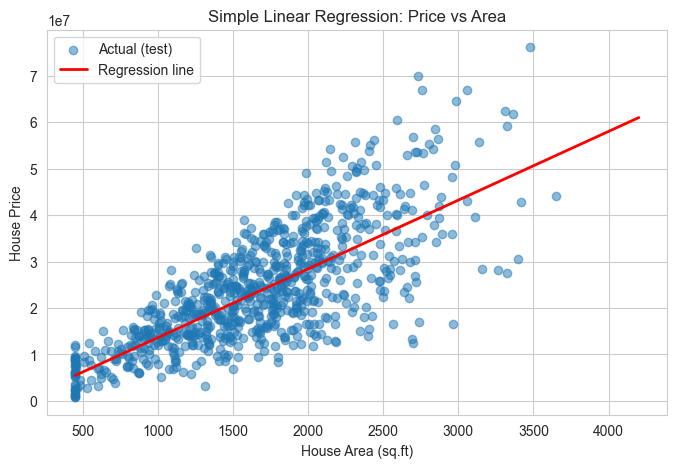

Equation: Price = -1,163,519 + 14,788.31 × Area
Interpretation: for every +1 sq.ft of area, price increases by about 14,788.31.
Intercept -1,163,519 is the predicted price when area = 0 (a mathematical baseline, not a real house).


In [14]:
plt.figure()
plt.scatter(Xte_area, y_test, alpha=0.5, label="Actual (test)")
xs = np.linspace(df["area_sqft"].min(), df["area_sqft"].max(), 100).reshape(-1, 1)
plt.plot(xs, slr.predict(xs), color="red", linewidth=2, label="Regression line")
plt.xlabel("House Area (sq.ft)"); plt.ylabel("House Price")
plt.title("Simple Linear Regression: Price vs Area")
plt.legend()
plt.savefig("plots/04_simple_regression_line.png", dpi=120); plt.show()

print(f"Equation: Price = {slr.intercept_:,.0f} + {slr.coef_[0]:,.2f} × Area")
print(f"Interpretation: for every +1 sq.ft of area, price increases by about {slr.coef_[0]:,.2f}.")
print(f"Intercept {slr.intercept_:,.0f} is the predicted price when area = 0 (a mathematical baseline, not a real house).")

**Interpretation:** The **slope** tells how much the price changes for each extra sq.ft of area (positive slope = bigger house costs more). The **intercept** is the base price when area is 0; it has no physical meaning by itself but positions the line.

### Q12. Validate linear regression assumptions using plots

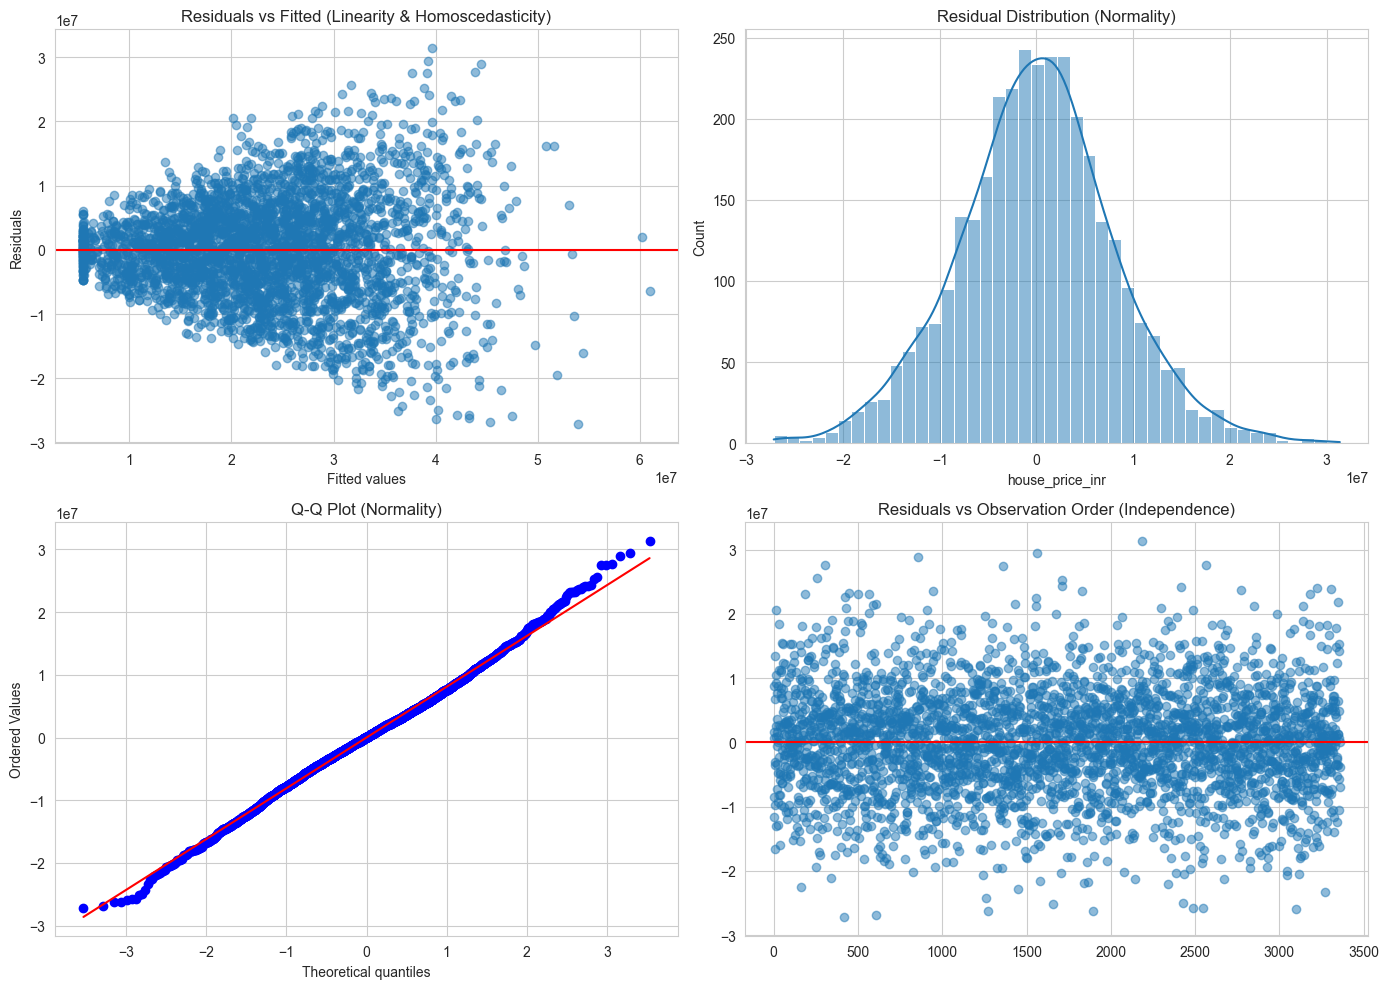

Durbin-Watson = 1.98  (≈2 means no autocorrelation)
Shapiro-Wilk normality p-value: 0.0 (> 0.05 → normal)


In [15]:
residuals = y_train - slr_train_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Linearity + Homoscedasticity : Residuals vs Fitted
axes[0, 0].scatter(slr_train_pred, residuals, alpha=0.5)
axes[0, 0].axhline(0, color="red")
axes[0, 0].set(title="Residuals vs Fitted (Linearity & Homoscedasticity)",
               xlabel="Fitted values", ylabel="Residuals")

# 2. Normality : Histogram
sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Residual Distribution (Normality)")

# 3. Normality : Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot (Normality)")

# 4. Independence : Residuals in order
axes[1, 1].plot(residuals.values, marker="o", linestyle="", alpha=0.5)
axes[1, 1].axhline(0, color="red")
axes[1, 1].set(title="Residuals vs Observation Order (Independence)")

plt.tight_layout(); plt.savefig("plots/05_assumption_checks.png", dpi=120); plt.show()

# Numeric checks
dw = np.sum(np.diff(residuals)**2) / np.sum(residuals**2)
print(f"Durbin-Watson = {dw:.2f}  (≈2 means no autocorrelation)")
print("Shapiro-Wilk normality p-value:", round(stats.shapiro(residuals)[1], 4), "(> 0.05 → normal)")

**Observations (write according to your plots):**
- **Linearity:** if residuals scatter randomly around 0 with no curve → linear assumption OK; a U-shape means the relation is non-linear.
- **Homoscedasticity:** if the spread of residuals is roughly equal (no funnel shape) → OK.
- **Normality:** histogram bell-shaped and Q-Q points near the red line → OK.
- **Independence:** Durbin-Watson close to 2 → residuals are independent.

# Part D: Model Evaluation Metrics

### Q13. Evaluate the Simple Linear Regression model

In [16]:
def evaluate(y_true, y_pred, n_features):
    n = len(y_true)
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    adj  = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2, "Adj_R2": adj}

results = {}
results["Simple LR"] = evaluate(y_test, slr_test_pred, n_features=1)
pd.DataFrame(results).T

,MSE,MAE,RMSE,R2,Adj_R2
Simple LR,6.698926e+13,6.294594e+06,8.184697e+06,0.56252,0.561998


### Q14. Interpret each metric

| Metric | Meaning | What it reveals about our model |
|---|---|---|
| **MSE** | Average of squared errors. Big errors are punished heavily. Unit = price². | Lower is better; hard to read directly because of squared unit. |
| **MAE** | Average absolute error. | On average, predictions are off by this many rupees/dollars. Less sensitive to outliers. |
| **RMSE** | √MSE, same unit as price. | Typical size of prediction error; larger than MAE when big errors exist. |
| **R² Score** | Fraction of price variance explained by the model (0 to 1). | e.g. 0.65 → model explains 65% of variation; the rest is due to other factors. |
| **Adjusted R²** | R² penalised for number of features. | Increases only if a new feature really helps; used to compare models with different feature counts. |

**Conclusion:** Simple LR uses only *Area*, so it usually has moderate R² and large RMSE — other features (location, rooms, age, distance, lot size, garage, pool) are ignored, which motivates Multiple Linear Regression.

# Part E: Multiple Linear Regression

### Q15. Implement Multiple Linear Regression using all relevant features

In [17]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)
mlr_test_pred = mlr.predict(X_test)

coef_table = pd.DataFrame({"Feature": FEATURES, "Coefficient": mlr.coef_})
print("Intercept:", mlr.intercept_)
display(coef_table)

results["Multiple LR"] = evaluate(y_test, mlr_test_pred, n_features=len(FEATURES))
pd.DataFrame(results).T

Intercept: -14766762.745674264


,Feature,Coefficient
0,area_sqft,1.379594e+04
1,bedrooms,1.976431e+05
2,bathrooms,1.859445e+05
3,location_score,3.073174e+06
4,age_years,-6.560924e+04
5,distance_city_km,-9.896516e+04
6,lot_size_sqft,1.035058e+02
7,has_garage,9.392436e+04
8,has_pool,4.552902e+05
9,renovation_years_ago,-2.143591e+04


,MSE,MAE,RMSE,R2,Adj_R2
Simple LR,6.698926e+13,6.294594e+06,8.184697e+06,0.562520,0.561998
Multiple LR,1.259292e+13,2.604991e+06,3.548650e+06,0.917761,0.916769


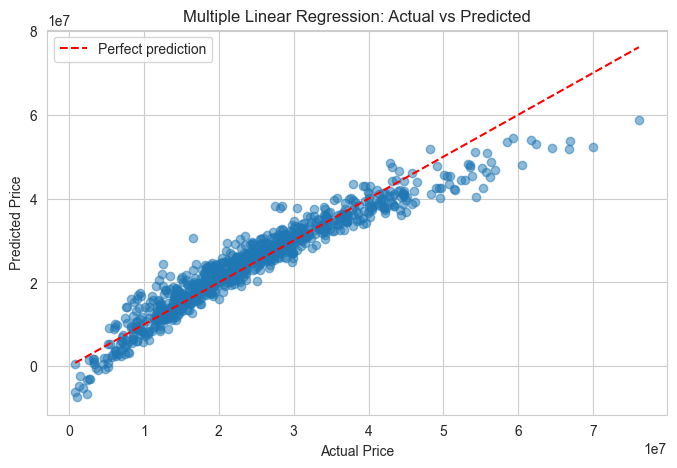

In [18]:
# Actual vs Predicted plot
plt.figure()
plt.scatter(y_test, mlr_test_pred, alpha=0.5)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Price"); plt.ylabel("Predicted Price")
plt.title("Multiple Linear Regression: Actual vs Predicted"); plt.legend()
plt.savefig("plots/06_mlr_actual_vs_pred.png", dpi=120); plt.show()

### Q16. Compare performance with Simple Linear Regression

,MSE,MAE,RMSE,R2,Adj_R2
Simple LR,6.698926e+13,6.294594e+06,8.184697e+06,0.562520,0.561998
Multiple LR,1.259292e+13,2.604991e+06,3.548650e+06,0.917761,0.916769


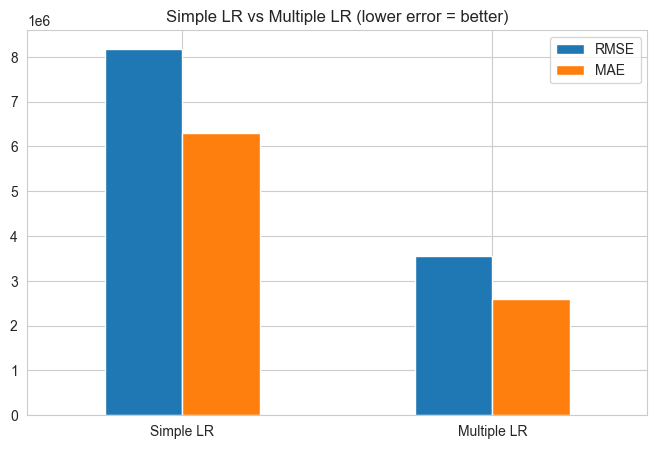

In [19]:
comp = pd.DataFrame(results).T.loc[["Simple LR", "Multiple LR"]]
display(comp)

comp[["RMSE", "MAE"]].plot(kind="bar", rot=0)
plt.title("Simple LR vs Multiple LR (lower error = better)")
plt.savefig("plots/07_slr_vs_mlr.png", dpi=120); plt.show()

### Q17. Why does performance improve or degrade?

**Answer:** Multiple Linear Regression normally **improves** performance (lower MSE/MAE/RMSE, higher R² and Adjusted R²) because:
1. House price depends on many factors (location, bedrooms, bathrooms, age), not only area. MLR uses all this information.
2. It reduces **bias** (less underfitting) because the model can explain more variance.
3. Adjusted R² also increases, which proves the extra features are genuinely useful, not just adding noise.

**When it can degrade:** if features are irrelevant or highly correlated with each other (**multicollinearity**), or if there is very little data, the extra features can add noise and increase variance (overfitting).

# Part F: Polynomial Regression

### Q18. Implement Polynomial Regression (degree 2 and 3)

In [20]:
def poly_model(degree):
    return make_pipeline(PolynomialFeatures(degree, include_bias=False),
                         StandardScaler(),
                         LinearRegression())

poly_preds = {}
for d in [2, 3]:
    m = poly_model(d).fit(X_train, y_train)
    poly_preds[d] = m
    results[f"Polynomial (deg {d})"] = evaluate(y_test, m.predict(X_test), n_features=m[0].n_output_features_)
    print(f"Degree {d}: {m[0].n_output_features_} features after expansion")

pd.DataFrame(results).T

Degree 2: 65 features after expansion
Degree 3: 285 features after expansion


,MSE,MAE,RMSE,R2,Adj_R2
Simple LR,6.698926e+13,6.294594e+06,8.184697e+06,0.562520,0.561998
Multiple LR,1.259292e+13,2.604991e+06,3.548650e+06,0.917761,0.916769
Polynomial (deg 2),5.139491e+12,1.656923e+06,2.267045e+06,0.966436,0.963617
Polynomial (deg 3),5.413690e+12,1.707651e+06,2.326734e+06,0.964645,0.946458


### Q19. Compare Linear vs Polynomial visually and numerically

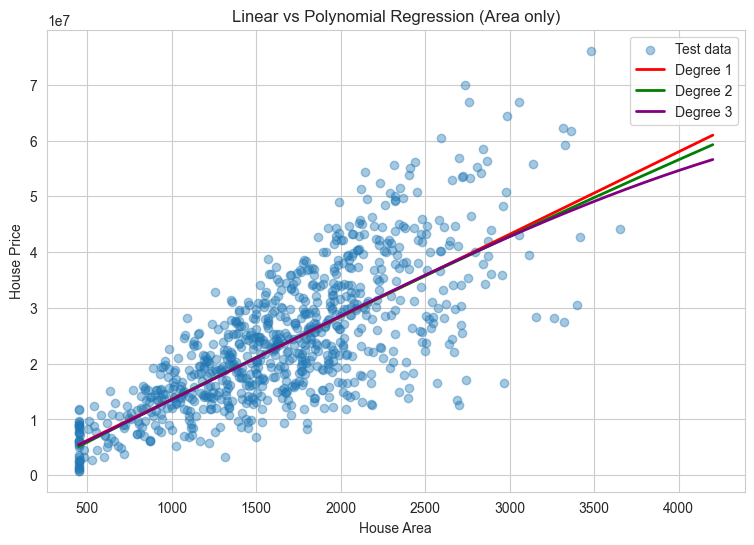

In [21]:
xs = np.linspace(df["area_sqft"].min(), df["area_sqft"].max(), 300).reshape(-1, 1)

plt.figure(figsize=(9, 6))
plt.scatter(Xte_area, y_test, alpha=0.4, label="Test data")
for d, color in [(1, "red"), (2, "green"), (3, "purple")]:
    m = poly_model(d).fit(Xtr_area, y_train)
    plt.plot(xs, m.predict(xs), color=color, linewidth=2, label=f"Degree {d}")
plt.xlabel("House Area"); plt.ylabel("House Price")
plt.title("Linear vs Polynomial Regression (Area only)"); plt.legend()
plt.savefig("plots/08_linear_vs_polynomial.png", dpi=120); plt.show()

In [22]:
display(pd.DataFrame(results).T.loc[["Simple LR", "Multiple LR", "Polynomial (deg 2)", "Polynomial (deg 3)"]])

,MSE,MAE,RMSE,R2,Adj_R2
Simple LR,6.698926e+13,6.294594e+06,8.184697e+06,0.562520,0.561998
Multiple LR,1.259292e+13,2.604991e+06,3.548650e+06,0.917761,0.916769
Polynomial (deg 2),5.139491e+12,1.656923e+06,2.267045e+06,0.966436,0.963617
Polynomial (deg 3),5.413690e+12,1.707651e+06,2.326734e+06,0.964645,0.946458


### Q20. Identify signs of Overfitting or Underfitting

,Degree,Train R2,Test R2
0,1,0.572307,0.562520
1,2,0.572467,0.562692
2,3,0.572575,0.562874
3,5,0.572731,0.562745
4,8,0.573714,0.561822


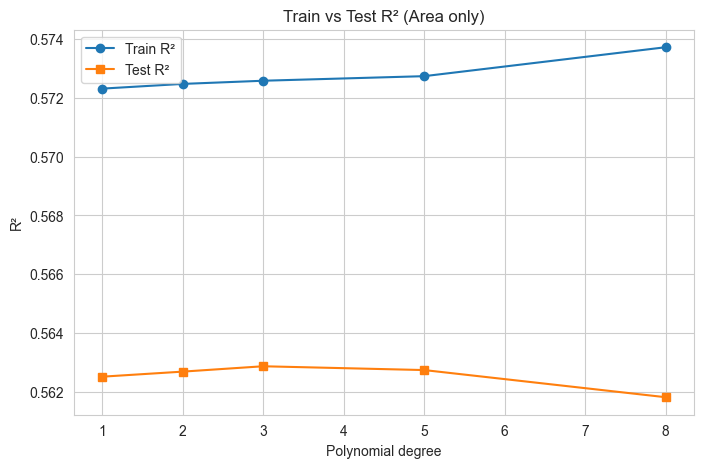

In [23]:
rows = []
for d in [1, 2, 3, 5, 8]:
    m = poly_model(d).fit(Xtr_area, y_train)
    rows.append({"Degree": d,
                 "Train R2": r2_score(y_train, m.predict(Xtr_area)),
                 "Test R2":  r2_score(y_test,  m.predict(Xte_area))})
fit_df = pd.DataFrame(rows); display(fit_df)

plt.plot(fit_df["Degree"], fit_df["Train R2"], "o-", label="Train R²")
plt.plot(fit_df["Degree"], fit_df["Test R2"],  "s-", label="Test R²")
plt.xlabel("Polynomial degree"); plt.ylabel("R²"); plt.legend()
plt.title("Train vs Test R² (Area only)")
plt.savefig("plots/09_overfit_underfit_check.png", dpi=120); plt.show()

**Signs to look for:**
- **Underfitting:** low R² on *both* train and test (e.g. degree 1 when data is curved).
- **Overfitting:** Train R² is very high but Test R² drops or the gap becomes large (high degree).
- **Good fit:** both are high and close (usually degree 2 or 3).

# Part G: Gradient Descent Optimization

### Q21. Explain Gradient Descent conceptually
**Gradient Descent** is an optimisation algorithm that finds the model parameters (θ) which minimise the cost function (MSE). Think of walking down a hill in fog: at every step you check the slope and move in the downhill direction.

**Update rule:** `θ = θ − α × ∂J/∂θ`
where **α (learning rate)** is the step size and **∂J/∂θ** is the gradient of the cost.
- α too small → very slow convergence. α too large → overshoots and may diverge.

**MSE cost:** `J(θ) = (1/m) Σ (ŷ − y)²`, gradient: `(2/m) Xᵀ(Xθ − y)`

**Three variants:** Batch (all samples per step), Stochastic (1 sample per step), Mini-Batch (small group per step).

In [24]:
x_scaler, y_scaler = StandardScaler(), StandardScaler()
Xtr_s = x_scaler.fit_transform(X_train)
Xte_s = x_scaler.transform(X_test)
ytr_s = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

Xtr_b = np.c_[np.ones(len(Xtr_s)), Xtr_s]
Xte_b = np.c_[np.ones(len(Xte_s)), Xte_s]

def mse_cost(X, y, theta):
    return np.mean((X @ theta - y) ** 2)

### Q22. Batch Gradient Descent from scratch

In [25]:
def batch_gd(X, y, lr=0.1, epochs=200):
    m, n = X.shape
    theta = np.zeros(n)
    history = []
    for _ in range(epochs):
        grad = (2 / m) * X.T @ (X @ theta - y)
        theta -= lr * grad
        history.append(mse_cost(X, y, theta))
    return theta, history

t0 = time.time()
theta_bgd, hist_bgd = batch_gd(Xtr_b, ytr_s, lr=0.1, epochs=200)
time_bgd = time.time() - t0
print("Batch GD  | final cost:", round(hist_bgd[-1], 5), "| time:", round(time_bgd, 4), "s")

Batch GD  | final cost: 0.07528 | time: 0.0553 s


### Q23. Stochastic Gradient Descent (SGD)

In [26]:
def sgd(X, y, lr=0.01, epochs=50):
    m, n = X.shape
    theta = np.zeros(n)
    history = []
    rng = np.random.default_rng(RANDOM_STATE)
    for _ in range(epochs):
        for i in rng.permutation(m):
            xi, yi = X[i], y[i]
            grad = 2 * xi * (xi @ theta - yi)
            theta -= lr * grad
        history.append(mse_cost(X, y, theta))
    return theta, history

t0 = time.time()
theta_sgd, hist_sgd = sgd(Xtr_b, ytr_s, lr=0.01, epochs=50)
time_sgd = time.time() - t0
print("SGD       | final cost:", round(hist_sgd[-1], 5), "| time:", round(time_sgd, 4), "s")

SGD       | final cost: 0.10436 | time: 1.5162 s


### Q24. Mini-Batch Gradient Descent

In [27]:
def minibatch_gd(X, y, lr=0.05, epochs=100, batch_size=32):
    m, n = X.shape
    theta = np.zeros(n)
    history = []
    rng = np.random.default_rng(RANDOM_STATE)
    for _ in range(epochs):
        idx = rng.permutation(m)
        for start in range(0, m, batch_size):
            b = idx[start:start + batch_size]
            Xb_, yb_ = X[b], y[b]
            grad = (2 / len(b)) * Xb_.T @ (Xb_ @ theta - yb_)
            theta -= lr * grad
        history.append(mse_cost(X, y, theta))
    return theta, history

t0 = time.time()
theta_mbgd, hist_mbgd = minibatch_gd(Xtr_b, ytr_s, lr=0.05, epochs=100, batch_size=32)
time_mbgd = time.time() - t0
print("Mini-Batch| final cost:", round(hist_mbgd[-1], 5), "| time:", round(time_mbgd, 4), "s")

Mini-Batch| final cost: 0.07652 | time: 0.1478 s


### Q25. Compare convergence behaviour and training time

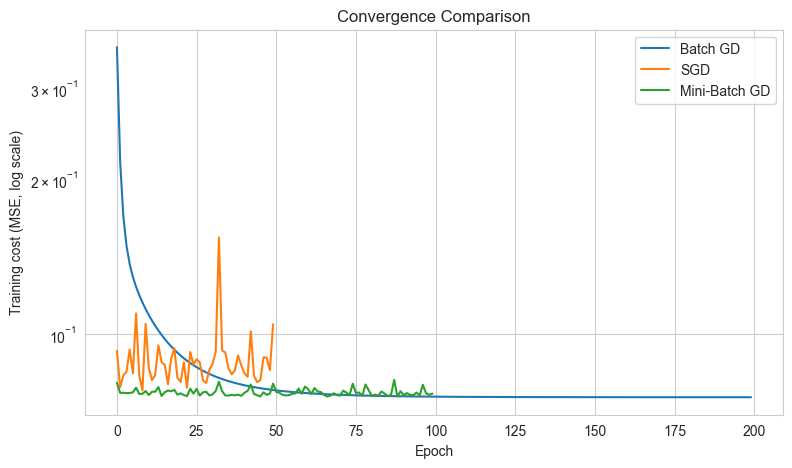

,Method,Epochs,Final train cost,Time (s),Test RMSE,Test R2
0,Batch GD,200,0.075280,0.055297,3.549154e+06,0.917737
1,SGD,50,0.104356,1.516223,4.275429e+06,0.880625
2,Mini-Batch GD,100,0.076519,0.147782,3.589179e+06,0.915871


Test RMSE of sklearn Multiple LR: 3548650.29


In [28]:
plt.figure(figsize=(9, 5))
plt.plot(hist_bgd,   label="Batch GD")
plt.plot(hist_sgd,   label="SGD")
plt.plot(hist_mbgd,  label="Mini-Batch GD")
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Training cost (MSE, log scale)")
plt.title("Convergence Comparison"); plt.legend()
plt.savefig("plots/10_gd_convergence.png", dpi=120); plt.show()

def gd_predict(theta):
    return y_scaler.inverse_transform((Xte_b @ theta).reshape(-1, 1)).ravel()

gd_table = []
for name, th, tt, hist in [("Batch GD", theta_bgd, time_bgd, hist_bgd),
                           ("SGD", theta_sgd, time_sgd, hist_sgd),
                           ("Mini-Batch GD", theta_mbgd, time_mbgd, hist_mbgd)]:
    ev = evaluate(y_test, gd_predict(th), len(FEATURES))
    results[name] = ev
    gd_table.append({"Method": name, "Epochs": len(hist), "Final train cost": hist[-1],
                     "Time (s)": tt, "Test RMSE": ev["RMSE"], "Test R2": ev["R2"]})
display(pd.DataFrame(gd_table))

print("Test RMSE of sklearn Multiple LR:", round(results["Multiple LR"]["RMSE"], 2))

**Comparison:**

| Method | Convergence | Speed / Time | Notes |
|---|---|---|---|
| **Batch GD** | Smooth, stable curve | 1 update per epoch → fast for small data, slow for huge data | Exact gradient, needs full data in memory |
| **SGD** | Noisy, zig-zag curve | Many updates per epoch (Python loop → slowest here) | Good for very large data, can escape local minima |
| **Mini-Batch GD** | Fairly smooth and fast | Best balance | Most used in practice (deep learning) |

All three reach almost the same final cost/R² as the closed-form Multiple Linear Regression, which proves the implementation is correct.

# Part H: Bias Variance & Model Diagnostics

### Q26. Analyze bias and variance across Simple, Multiple and Polynomial Regression

,Train RMSE,Test RMSE,Bias²,Variance
Model,,,,
Simple LR,8.104428e+06,8.184697e+06,6.693675e+13,3.597340e+10
Multiple LR,3.400099e+06,3.548650e+06,1.259717e+13,4.203445e+10
Polynomial (deg 2),2.200985e+06,2.267045e+06,5.134842e+12,1.095277e+11
Polynomial (deg 3),2.103216e+06,2.326734e+06,5.414299e+12,6.029561e+11


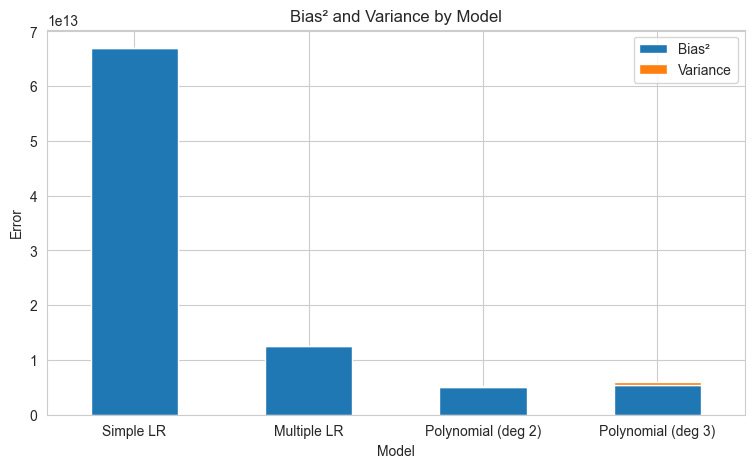

In [29]:
def bias_variance(make_model, cols, n_boot=100):
    """Estimate Bias² and Variance on test set using bootstrap resampling."""
    Xtr, Xte = X_train[cols].values, X_test[cols].values
    ytr, yte = y_train.values, y_test.values
    preds = np.zeros((n_boot, len(yte)))
    rng = np.random.default_rng(RANDOM_STATE)
    for b in range(n_boot):
        idx = rng.integers(0, len(Xtr), len(Xtr))
        preds[b] = make_model().fit(Xtr[idx], ytr[idx]).predict(Xte)
    avg = preds.mean(axis=0)
    bias2 = np.mean((avg - yte) ** 2)
    var = np.mean(preds.var(axis=0))
    return bias2, var

configs = {
    "Simple LR":          (lambda: LinearRegression(), ["area_sqft"]),
    "Multiple LR":        (lambda: LinearRegression(), FEATURES),
    "Polynomial (deg 2)": (lambda: poly_model(2), FEATURES),
    "Polynomial (deg 3)": (lambda: poly_model(3), FEATURES),
}

bv_rows = []
for name, (mk, cols) in configs.items():
    m = mk().fit(X_train[cols].values, y_train.values)
    tr_rmse = np.sqrt(mean_squared_error(y_train, m.predict(X_train[cols].values)))
    te_rmse = np.sqrt(mean_squared_error(y_test,  m.predict(X_test[cols].values)))
    b2, v = bias_variance(mk, cols)
    bv_rows.append({"Model": name, "Train RMSE": tr_rmse, "Test RMSE": te_rmse,
                    "Bias²": b2, "Variance": v})
bv_df = pd.DataFrame(bv_rows).set_index("Model")
display(bv_df)

bv_df[["Bias²", "Variance"]].plot(kind="bar", stacked=True, rot=0, figsize=(9, 5))
plt.title("Bias² and Variance by Model"); plt.ylabel("Error")
plt.savefig("plots/11_bias_variance.png", dpi=120); plt.show()

**Analysis:**
- **Simple LR** → high bias (only one feature, cannot capture full pattern), low variance.
- **Multiple LR** → lower bias (more information), still low variance.
- **Polynomial** → lowest bias, but variance increases as degree/feature count increases (more sensitive to training sample).

### Q27. How model complexity affects prediction error

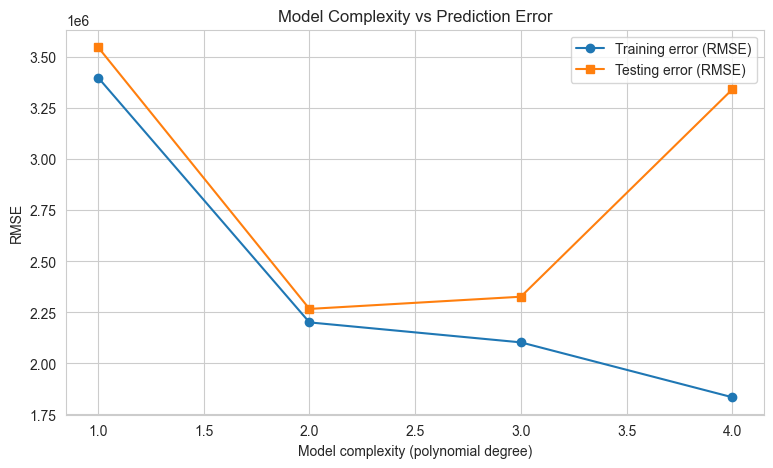

,Degree,Train RMSE,Test RMSE
0,1,3.400099e+06,3.548650e+06
1,2,2.200985e+06,2.267045e+06
2,3,2.103216e+06,2.326734e+06
3,4,1.834533e+06,3.341703e+06


In [30]:
degrees = [1, 2, 3, 4]
tr_err, te_err, cv_err = [], [], []
for d in degrees:
    m = poly_model(d).fit(X_train, y_train)
    tr_err.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train))))
    te_err.append(np.sqrt(mean_squared_error(y_test,  m.predict(X_test))))

plt.figure(figsize=(9, 5))
plt.plot(degrees, tr_err, "o-", label="Training error (RMSE)")
plt.plot(degrees, te_err, "s-", label="Testing error (RMSE)")
plt.xlabel("Model complexity (polynomial degree)"); plt.ylabel("RMSE")
plt.title("Model Complexity vs Prediction Error"); plt.legend()
plt.savefig("plots/12_complexity_vs_error.png", dpi=120); plt.show()
display(pd.DataFrame({"Degree": degrees, "Train RMSE": tr_err, "Test RMSE": te_err}))

**Answer:** As complexity increases, **training error keeps decreasing** (model fits training data better and better), but **testing error first decreases and then increases** (U-shape). Left side = underfitting (high bias), right side = overfitting (high variance). The best model is at the bottom of the test-error curve.

### Q28. Which model best balances bias and variance?

In [31]:
all_models = pd.DataFrame(results).T
best_name = all_models["RMSE"].idxmin()
print("Lowest test RMSE model overall:", best_name)

cv_rows = []
for name, (mk, cols) in configs.items():
    scores = cross_val_score(mk(), X[cols].values, y.values, cv=5, scoring="r2")
    cv_rows.append({"Model": name, "CV R2 mean": scores.mean(), "CV R2 std": scores.std()})
display(pd.DataFrame(cv_rows).set_index("Model"))

Lowest test RMSE model overall: Polynomial (deg 2)


,CV R2 mean,CV R2 std
Model,,
Simple LR,0.569239,0.012517
Multiple LR,0.922943,0.004127
Polynomial (deg 2),0.966638,0.003419
Polynomial (deg 3),0.963807,0.003706


**Answer:** The model with the **lowest test error, small gap between train and test error, and stable cross-validation score** is the best balanced one — normally **Multiple Linear Regression or Polynomial Regression (degree 2)**. Very high-degree polynomials have low bias but high variance, and Simple LR has low variance but high bias.

# Part I: Final Analysis & Reporting

### Q29. Summary of findings

,MSE,MAE,RMSE,R2,Adj_R2
Polynomial (deg 2),"5,139,490,891,510.790","1,656,922.802","2,267,044.528",0.966,0.964
Polynomial (deg 3),"5,413,689,759,326.558","1,707,651.435","2,326,733.710",0.965,0.946
Multiple LR,"12,592,918,884,127.742","2,604,991.406","3,548,650.290",0.918,0.917
Batch GD,"12,596,494,762,318.877","2,605,250.911","3,549,154.091",0.918,0.917
Mini-Batch GD,"12,882,203,047,323.953","2,650,619.755","3,589,178.603",0.916,0.915
SGD,"18,279,290,674,288.672","3,166,322.270","4,275,428.712",0.881,0.879
Simple LR,"66,989,260,021,849.469","6,294,593.696","8,184,696.697",0.563,0.562


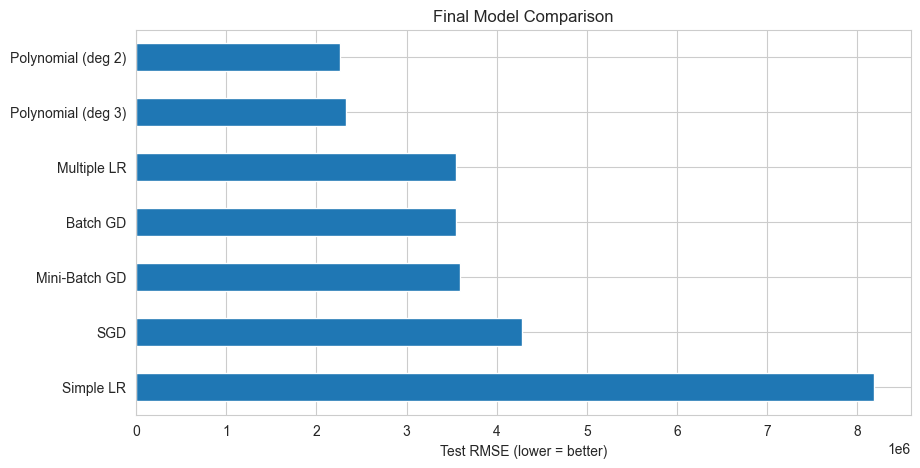

Best model: Polynomial (deg 2)


In [32]:
final = pd.DataFrame(results).T.sort_values("RMSE")
display(final.style.format("{:,.3f}"))

plt.figure(figsize=(10, 5))
final["RMSE"].plot(kind="barh")
plt.gca().invert_yaxis(); plt.xlabel("Test RMSE (lower = better)")
plt.title("Final Model Comparison")
plt.savefig("plots/13_final_comparison.png", dpi=120, bbox_inches="tight"); plt.show()

final.to_csv("model_evaluation_results.csv")
print("Best model:", final.index[0])

### Short Report

**1. Best-performing model and why:** Multiple Linear Regression / Polynomial Regression (degree 2) gave the lowest RMSE and highest Adjusted R² (check the table above). They use all features (all 10 features), so they capture more of the price variation than Simple Linear Regression, and they generalise well to the test set.

**2. Impact of Gradient Descent optimisation:** Batch, SGD and Mini-Batch Gradient Descent all converged to nearly the same parameters and accuracy as the closed-form solution. Feature scaling was very important for fast convergence. Batch GD was smooth, SGD was noisy but flexible, and Mini-Batch gave the best speed/stability balance.

**3. Evidence of overfitting/underfitting:** Simple LR showed **underfitting** (high bias, low R² on both sets). Very high-degree polynomials (e.g. degree 8) showed **overfitting** (train R² ≫ test R²). Degree 2–3 gave the best balance.

**4. Practical business interpretation:** A real-estate firm can use this model to quote a fair price for new listings, find under/over-priced houses, and know which factors matter most (area and location increase price; age reduces it). The RMSE gives the typical error a client should expect, so the model should be used as a decision aid alongside expert judgement.